First best

c:\Users\pc\Desktop\AIDC MASTER\ai\parkinson+dataset+with+replicated+acoustic+features\venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1-Score
0,Naïve Bayes,0.837500,0.858407,0.808333,0.832618
1,c-SVM,0.841667,0.859649,0.816667,0.837607
2,nu-SVM,0.845833,0.873874,0.808333,0.839827
3,MLP,0.812500,0.809917,0.816667,0.813278
4,KNN,0.841667,0.853448,0.825000,0.838983
5,Random Forest,0.816667,0.845455,0.775000,0.808696


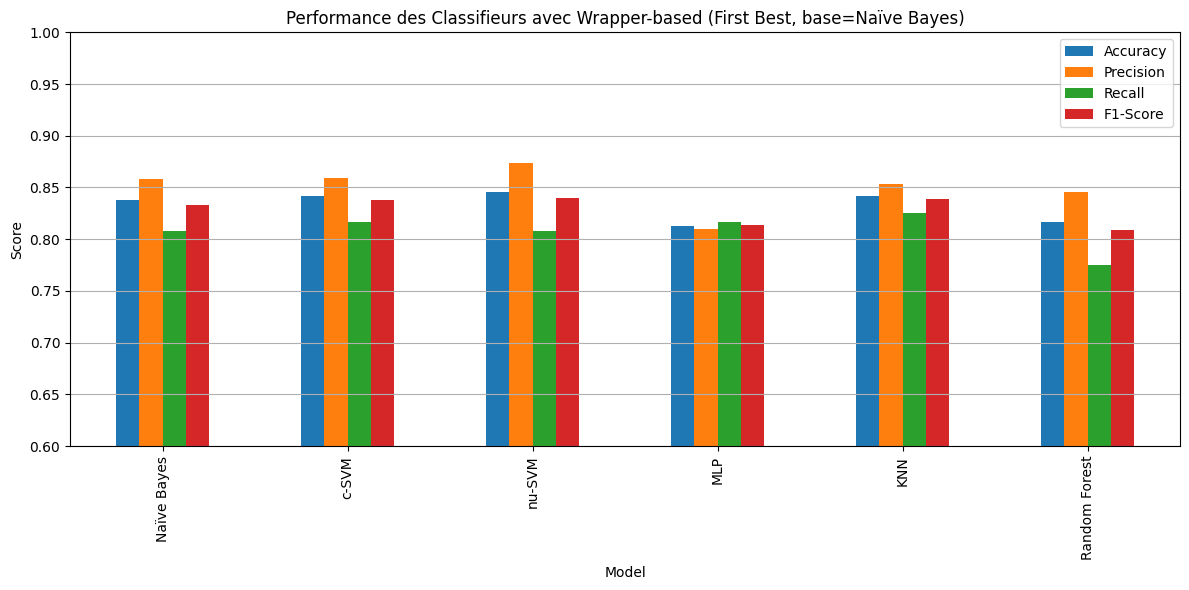

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC, NuSVC
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# 1. Chargement et préparation des données
df = pd.read_csv("parkinson.csv")
X = df.drop(columns=['ID', 'Recording', 'Status'])
y = df['Status']
X = pd.get_dummies(X, columns=['Gender'], drop_first=True)

# 2. Mise à l'échelle
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Sélection de caractéristiques par méthode wrapper (First Best) avec Naïve Bayes
selector = SequentialFeatureSelector(GaussianNB(), direction='forward', cv=5)
X_selected = selector.fit_transform(X_scaled, y)
selected_features = X.columns[selector.get_support()]

# 4. Définition des classifieurs
models = {
    'Naïve Bayes': GaussianNB(),
    'c-SVM': SVC(kernel='rbf', C=1.0),
    'nu-SVM': NuSVC(nu=0.5, kernel='rbf'),
    'MLP': MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, solver='adam', random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

# 5. Évaluation par validation croisée 10-fold
results = []
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for name, model in models.items():
    y_pred = cross_val_predict(model, X_selected, y, cv=kf)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y, y_pred),
        'Precision': precision_score(y, y_pred),
        'Recall': recall_score(y, y_pred),
        'F1-Score': f1_score(y, y_pred)
    })

# 6. Création du DataFrame et affichage
results_df = pd.DataFrame(results)
display(results_df)

# 7. Courbe de performance
results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-Score"]].plot(kind="bar", figsize=(12, 6))
plt.title("Performance des Classifieurs avec Wrapper-based (First Best, base=Naïve Bayes)")
plt.ylabel("Score")
plt.ylim(0.6, 1)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


 Greedy Stepwise


Résultats avec Wrapper-based (Greedy Stepwise, base = Naïve Bayes):

           Model  Accuracy  Precision    Recall  F1-Score
0    Naïve Bayes  0.837500   0.871560  0.791667  0.829694
1          c-SVM  0.825000   0.848214  0.791667  0.818966
2         nu-SVM  0.825000   0.842105  0.800000  0.820513
3            MLP  0.762500   0.773913  0.741667  0.757447
4            KNN  0.783333   0.769841  0.808333  0.788618
5  Random Forest  0.795833   0.819820  0.758333  0.787879


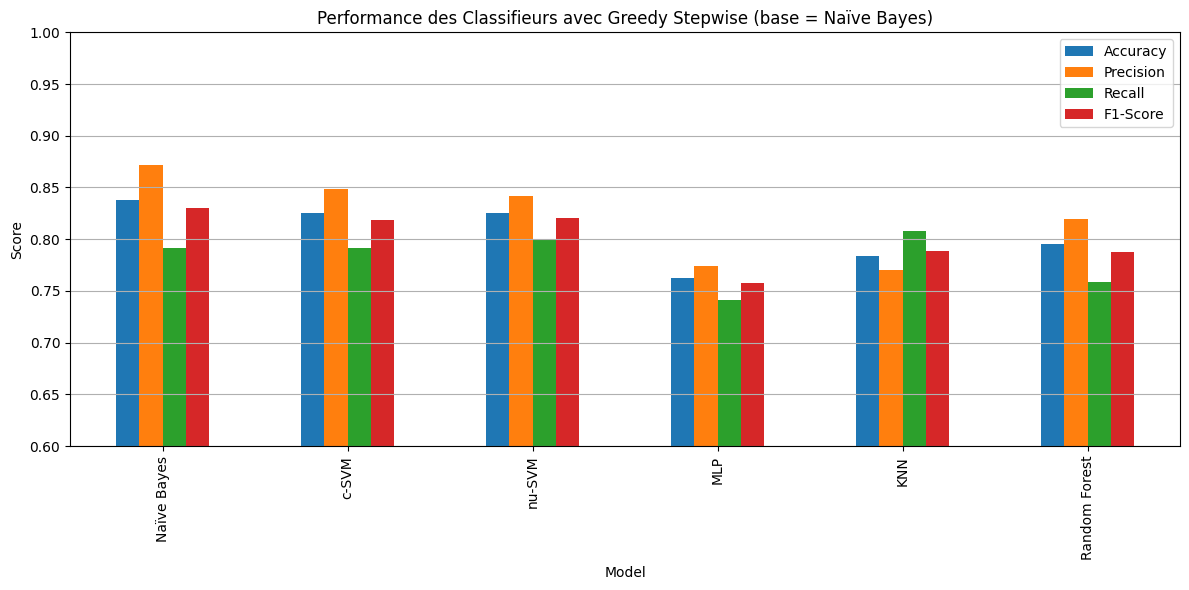

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC, NuSVC
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# 1. Chargement et préparation
df = pd.read_csv("parkinson.csv")
X = df.drop(columns=['ID', 'Recording', 'Status'])
y = df['Status']
X = pd.get_dummies(X, columns=['Gender'], drop_first=True)

# 2. Mise à l’échelle
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Sélection de caractéristiques avec Greedy Stepwise (forward + backward)
selector = SequentialFeatureSelector(
    estimator=GaussianNB(),
    direction='backward',  # Greedy Stepwise = backward + forward (tu peux tester 'forward' aussi)
    cv=5,
    n_jobs=-1
)
X_selected = selector.fit_transform(X_scaled, y)
selected_features = X.columns[selector.get_support()]

# 4. Définir les classifieurs
models = {
    'Naïve Bayes': GaussianNB(),
    'c-SVM': SVC(kernel='rbf', C=1.0),
    'nu-SVM': NuSVC(nu=0.5, kernel='rbf'),
    'MLP': MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

# 5. Évaluation croisée 10-fold
results = []
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for name, model in models.items():
    y_pred = cross_val_predict(model, X_selected, y, cv=kf)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y, y_pred),
        'Precision': precision_score(y, y_pred),
        'Recall': recall_score(y, y_pred),
        'F1-Score': f1_score(y, y_pred)
    })

# 6. Affichage des résultats
results_df = pd.DataFrame(results)
print("\nRésultats avec Wrapper-based (Greedy Stepwise, base = Naïve Bayes):\n")
print(results_df)

# 7. Courbe de performance
results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-Score"]].plot(kind="bar", figsize=(12, 6))
plt.title("Performance des Classifieurs avec Greedy Stepwise (base = Naïve Bayes)")
plt.ylabel("Score")
plt.ylim(0.6, 1)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


PSO Method

2025-06-19 23:15:16,030 - pyswarms.discrete.binary - INFO - Optimize for 30 iters with {'c1': 2, 'c2': 2, 'w': 0.9, 'k': 5, 'p': 2}
pyswarms.discrete.binary:   0%|          |0/30

pyswarms.discrete.binary: 100%|██████████|30/30, best_cost=0.15 
2025-06-19 23:15:21,620 - pyswarms.discrete.binary - INFO - Optimization finished | best cost: 0.15000000000000002, best pos: [0 0 0 0 1 1 1 0 1 1 1 1 1 1 1 0 0 1 0 0 0 1 0 1 1 0 0 1 1 0 0 0 1 0 1 0 0
 1 0 0 0 1 1 1 1]


Nombre de caractéristiques sélectionnées : 23

Résultats avec Wrapper PSO (base = Naïve Bayes pour sélection des features)



,Model,Accuracy,Precision,Recall,F1-Score
0,Naïve Bayes,0.829167,0.843478,0.808333,0.825532
1,c-SVM,0.825000,0.842105,0.800000,0.820513
2,nu-SVM,0.829167,0.837607,0.816667,0.827004
3,MLP,0.820833,0.834783,0.800000,0.817021
4,KNN,0.854167,0.851240,0.858333,0.854772
5,Random Forest,0.812500,0.820513,0.800000,0.810127


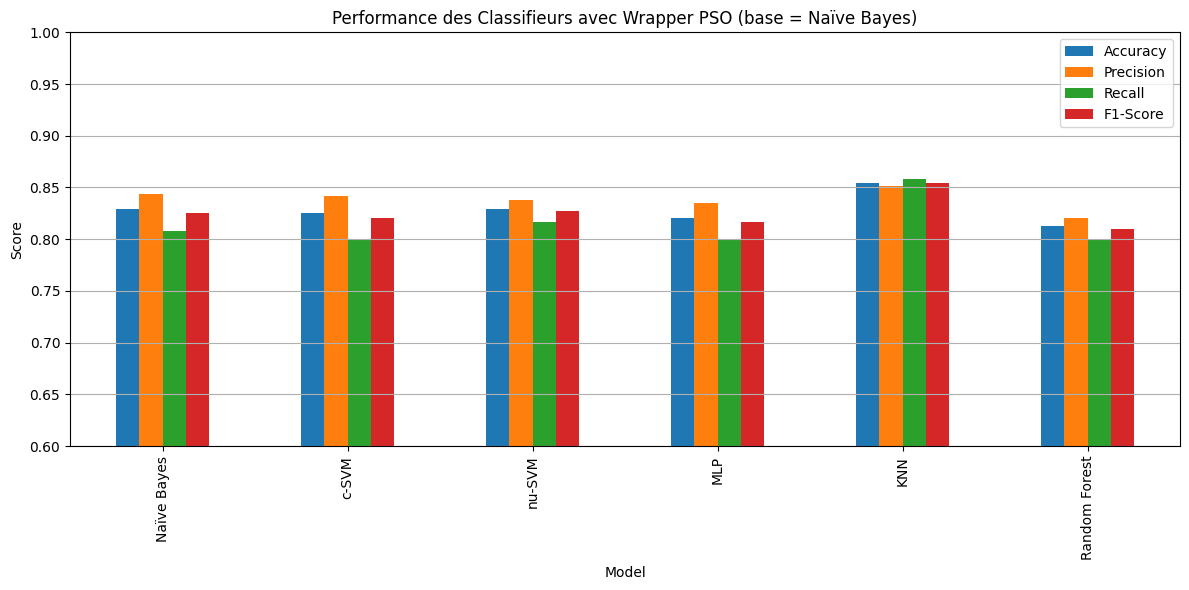

In [11]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC, NuSVC
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
import pyswarms as ps
import matplotlib.pyplot as plt

# 1. Charger et préparer les données
df = pd.read_csv("parkinson.csv")
X = df.drop(columns=['ID', 'Recording', 'Status'])
y = df['Status']
X = pd.get_dummies(X, columns=['Gender'], drop_first=True)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2. Définir la fonction d’évaluation du sous-ensemble (fitness)
def fitness_function(particles):
    scores = []
    for particle in particles:
        mask = particle > 0.5
        if np.sum(mask) == 0:
            scores.append(1.0)  # Mauvais score si aucune feature n'est sélectionnée
            continue
        X_selected = X_scaled[:, mask]
        score = cross_val_score(GaussianNB(), X_selected, y, cv=5, scoring='accuracy').mean()
        scores.append(1 - score)  # car on minimise
    return np.array(scores)

# 3. Configurer le PSO
n_particles = 20
dimensions = X_scaled.shape[1]

options = {'c1': 2, 'c2': 2, 'w': 0.9, 'k': 5, 'p': 2}
optimizer = ps.discrete.BinaryPSO(n_particles=n_particles, dimensions=dimensions, options=options)

# 4. Optimiser
best_cost, best_pos = optimizer.optimize(fitness_function, iters=30)

# 5. Extraire les meilleures features sélectionnées
selected_mask = best_pos > 0.5
X_selected_pso = X_scaled[:, selected_mask]
print(f"Nombre de caractéristiques sélectionnées : {np.sum(selected_mask)}")

# 6. Modèles à évaluer
models = {
    'Naïve Bayes': GaussianNB(),
    'c-SVM': SVC(kernel='rbf'),
    'nu-SVM': NuSVC(nu=0.5, kernel='rbf'),
    'MLP': MLPClassifier(hidden_layer_sizes=(100,), max_iter=2000, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

# 7. Évaluation croisée
results = []
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for name, model in models.items():
    y_pred = cross_val_predict(model, X_selected_pso, y, cv=kf)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y, y_pred),
        'Precision': precision_score(y, y_pred),
        'Recall': recall_score(y, y_pred),
        'F1-Score': f1_score(y, y_pred)
    })

# 8. Résultats
results_df = pd.DataFrame(results)
print("\nRésultats avec Wrapper PSO (base = Naïve Bayes pour sélection des features)\n")
display(results_df)

# 9. Graphique
results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-Score"]].plot(kind="bar", figsize=(12, 6))
plt.title("Performance des Classifieurs avec Wrapper PSO (base = Naïve Bayes)")
plt.ylabel("Score")
plt.ylim(0.6, 1)
plt.grid(axis='y')
plt.tight_layout()
plt.show()
